# Tag Recommendation Experiment (RecSys 2018)

Notebook simple et modulaire pour reproduire une expérience inspirée de l'article **Semantic-based Tag Recommendation in Scientific Bookmarking Systems**.

- Import des données : **1 cellule**
- Une fonction par cellule
- Visualisations déplacées dans `src/visualization.py`
- Dernière cellule : compilation des résultats + visualisations comparatives

In [1]:
import os

FORCE_CPU = True

if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

if FORCE_CPU:
    print(f"TF {tf.__version__} — forced CPU")
else:
    print(f"TF {tf.__version__} — GPUs: {tf.config.list_physical_devices('GPU')}")
    for g in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(g, True)
    tf.config.experimental.enable_tensor_float_32_execution(True)

device = "/CPU:0" if FORCE_CPU else "/GPU:0"
with tf.device(device):
    a = tf.random.normal((1024, 1024))
    _ = tf.matmul(a, a).numpy().sum()
print(f"{'CPU' if FORCE_CPU else 'GPU'} OK on {a.device}")

2026-04-17 16:07:02.440550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-17 16:07:02.471510: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-17 16:07:02.477441: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TF 2.17.0 — forced CPU
CPU OK on /job:localhost/replica:0/task:0/device:CPU:0


2026-04-17 16:07:05.509771: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
# Cellule 1 - Imports (meme stack que l'article)
import sys
from pathlib import Path
import subprocess
import os

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import (
    load_citeulike_a_dataset, 
    keep_top_k_tags, 
    preprocess_text_nltk, 
    text_length_stats,
    build_sentence_preprocessed
)
from src.experiment import prepare_train_test, run_all_models, run_all_models_hierarchical
from src.visualization import (
    plot_tag_distribution,
    plot_text_length_distributions,
    plot_model_metrics,
    plot_article_vs_current,
    plot_tag_cooccurrence_heatmap,
    plot_tag_frequency_pareto,
    plot_preprocessing_impact,
    plot_sentences_per_doc,
    plot_training_history,
    plot_training_time,
    plot_per_tag_f1,
    plot_threshold_sensitivity,
    plot_precision_recall_scatter,
    plot_topk_sensitivity,
)
from src.results_save import save_metrics_enriched

# pd.set_option("display.max_colwidth", 120)

In [3]:
# Cellule 2 - Paramètres globaux
DATA_PATH = Path(PROJECT_ROOT / "data" / "citeulike-a")
if not os.path.exists(DATA_PATH):
    print("target =", DATA_PATH.resolve())
    print("exists =", DATA_PATH.exists())
    if not DATA_PATH.exists():
        DATA_PATH.mkdir(parents=True, exist_ok=True)
        result = subprocess.run(
            ["bash","-c", f"git clone https://github.com/js05212/citeulike-a.git data/citeulike-a"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {DATA_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
GLOVE_PATH = Path(PROJECT_ROOT / "data" / "glove.6B.300d.txt")
if not os.path.exists(GLOVE_PATH):
    print("target =", GLOVE_PATH.resolve())
    print("exists =", GLOVE_PATH.exists())
    if not GLOVE_PATH.exists():
        result = subprocess.run(
            ["bash","-c", "curl -L -o data/glove.6B.zip \
            https://nlp.stanford.edu/data/glove.6B.zip"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "unzip data/glove.6B.zip -d data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {GLOVE_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
TOP_K_TAGS = 10
TEST_SIZE = 0.1
RANDOM_STATE = 42

/workspace/data/citeulike-a/citations.dat
/workspace/data/citeulike-a/item-tag.dat
/workspace/data/citeulike-a/mult.dat
/workspace/data/citeulike-a/tags.dat
/workspace/data/citeulike-a/users.dat
/workspace/data/citeulike-a/vocabulary.dat
[Fig] Pareto des tags — part cumulée des occurrences pour les tags triés par fréquence (axe X log). Corpus : 46388 tags uniques. À la coupure top-10, on couvre 4.8% des occurrences totales.
[Fig] Tag Co-occurrence (Jaccard) — heatmap symétrique des 15 tags les plus fréquents. Case claire = les deux tags apparaissent souvent ensemble. Utile pour expliquer les confusions inter-tags en multi-label.


,title,abstract,tags,text,tag_list,processed_text,processed_sentences,title_words,abstract_words,text_words,num_tags
0,The metabolic world of Escherichia coli is not...,To elucidate the organizational and evolutiona...,dissertation|metabolism|network|metabolic_netw...,The metabolic world of Escherichia coli is not...,"[network, review, networks]",metabolic world escherichia coli small elucida...,metabolic world escherichia coli small . eluci...,9,174,119,3
1,Reverse Engineering of Biological Complexity,Advanced technologies and biology have extreme...,behaviors|control|controllability|key--systems...,Reverse Engineering of Biological Complexity. ...,"[networks, network, review, evolution]",reverse engineering biological complexity adva...,reverse engineering biological complexity . ad...,5,123,82,4
2,Exploring complex networks,"The study of networks pervades all of science,...",scalefree|bistability|senior-project|complex-n...,Exploring complex networks. The study of netwo...,"[networks, statistics, network, review]",exploring complex network study network pervad...,exploring complex network . study network perv...,3,99,63,4
3,Comparative assessment of large-scale data set...,Comprehensive protein protein interaction maps...,false|features|pin|network_confidence|ppi|two-...,Comparative assessment of large-scale data set...,"[networks, network, statistics, bioinformatics...",comparative assessment large scale data set pr...,comparative assessment large scale data set pr...,9,61,50,5
4,Navigation in a small world,The small-world phenomenon â the principle t...,diktyology|complex-networks|filing-small-world...,Navigation in a small world. The small-world p...,"[networks, network, analysis]",navigation small world small world phenomenon ...,navigation small world . small world phenomeno...,5,103,60,3


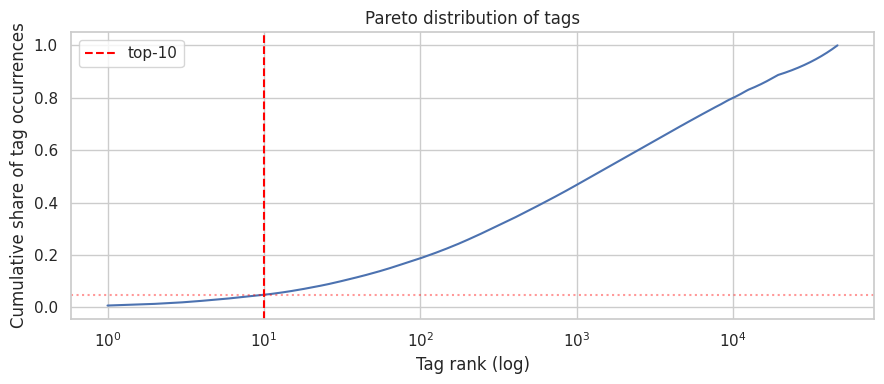

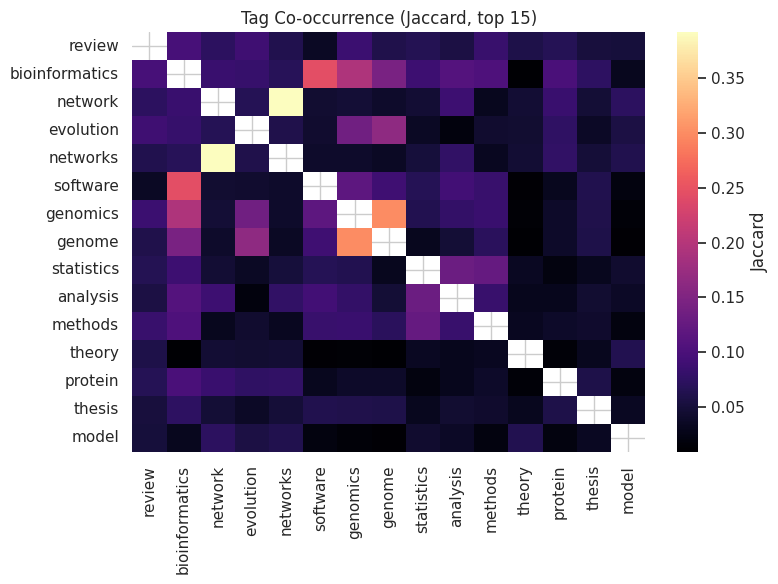

In [4]:
# Cellule 3 - Import des données (simple, en une cellule)
def import_data(csv_path: str | Path, top_k_tags: int = 10):
    df = load_citeulike_a_dataset(csv_path, normalize_tags=False)
    from src.visualization import plot_tag_cooccurrence_heatmap, plot_tag_frequency_pareto
    plot_tag_frequency_pareto(df, cutoff_k=10)
    plot_tag_cooccurrence_heatmap(df, top_n=15)
    df = keep_top_k_tags(df, top_k=top_k_tags)
    df = preprocess_text_nltk(df)
    df = build_sentence_preprocessed(df)
    return text_length_stats(df)


df = import_data(DATA_PATH, TOP_K_TAGS)
df.head()

In [5]:
# Cellule 4 - Fonction de résumé exploration
def summarize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    summary = {
        "num_documents": [len(df)],
        "num_unique_tags": [len({t for tags in df["tag_list"] for t in tags})],
        "avg_title_words": [df["title_words"].mean()],
        "avg_abstract_words": [df["abstract_words"].mean()],
        "avg_tags_per_doc": [df["num_tags"].mean()],
        "vocabulary_size" : len(set(" ".join(df["processed_text"]).split()))
    }
    return pd.DataFrame(summary)


summarize_dataset(df)

,num_documents,num_unique_tags,avg_title_words,avg_abstract_words,avg_tags_per_doc,vocabulary_size
0,6397,10,8.882132,180.848835,1.802251,30799


[Fig] Pareto des tags — part cumulée des occurrences pour les tags triés par fréquence (axe X log). Corpus : 10 tags uniques. À la coupure top-10, on couvre 100.0% des occurrences totales.
[Fig] Top Tag Distribution — fréquence des 10 tags les plus courants dans le corpus (plus la barre est longue, plus le tag apparaît souvent).
[Fig] Tag Co-occurrence (Jaccard) — heatmap symétrique des 10 tags les plus fréquents. Case claire = les deux tags apparaissent souvent ensemble. Utile pour expliquer les confusions inter-tags en multi-label.
[Fig] Text Length Distributions — trois histogrammes côte à côte : longueur des titres (mots), longueur des résumés (mots), et nombre de tags par document. Sert à caler les hyperparamètres (max_len, max_words).


/workspace/src/visualization.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")


[Fig] Impact du prétraitement NLTK — superpose la distribution du nombre de tokens par document AVANT (bleu) et APRÈS (rouge) nettoyage (stopwords + lemmatization). Réduction globale ≈ 34.4% du volume de tokens.
[Fig] Phrases par document — histogramme du nombre de phrases après segmentation. Médiane = 8. La barre rouge marque le plafond max_sentences=10 utilisé par HAN ; 27.7% des documents sont tronqués à cette valeur.


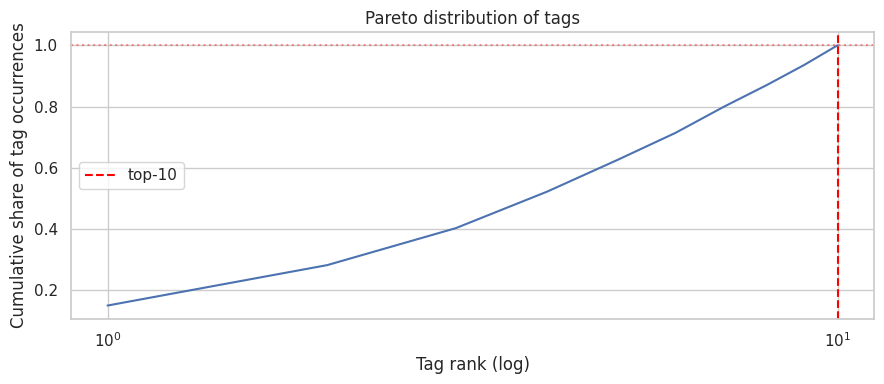

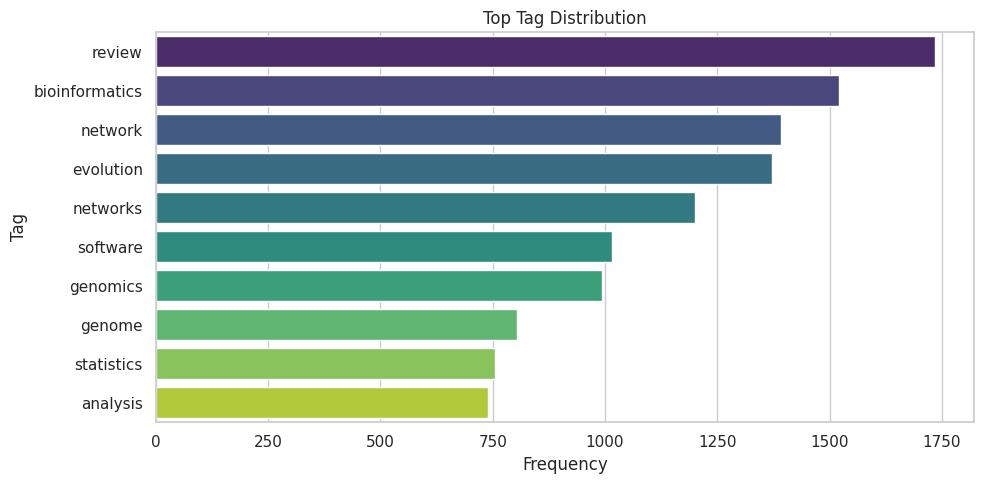

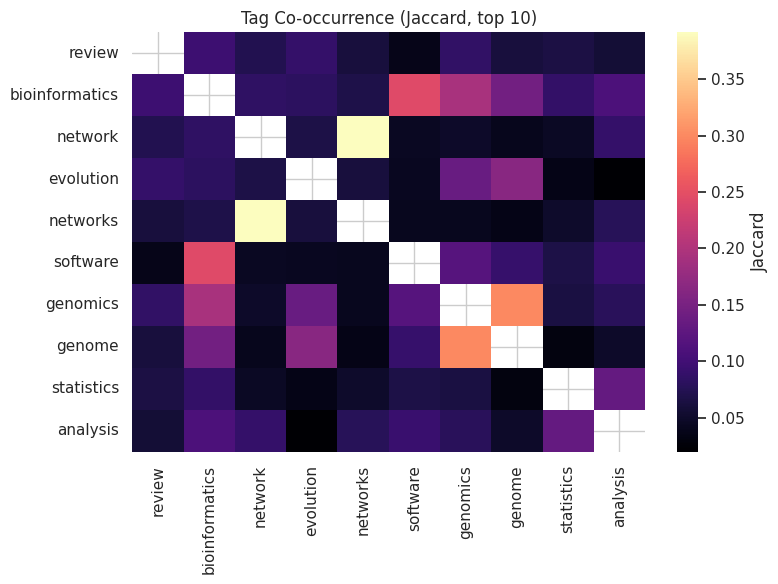

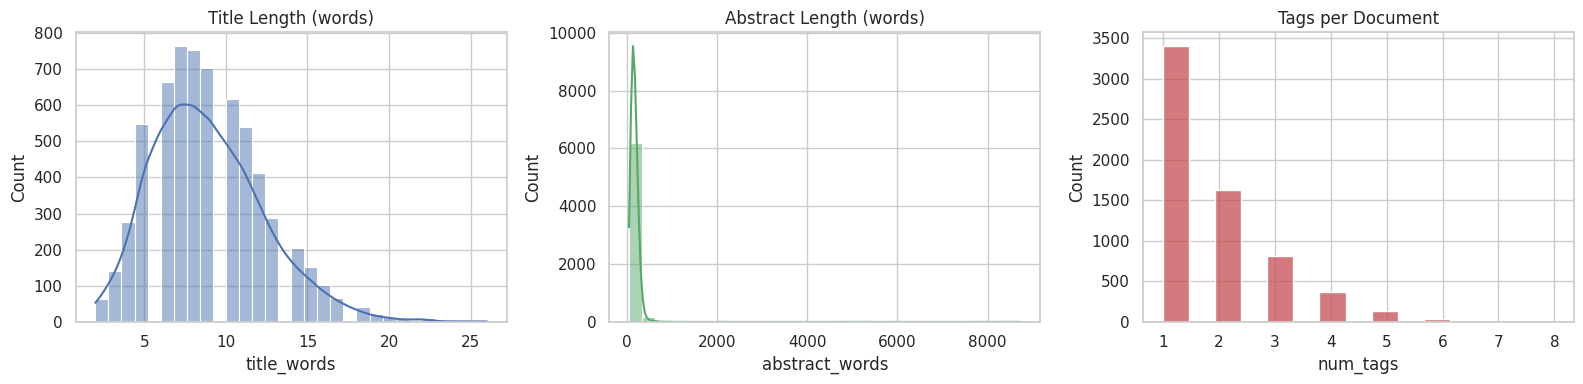

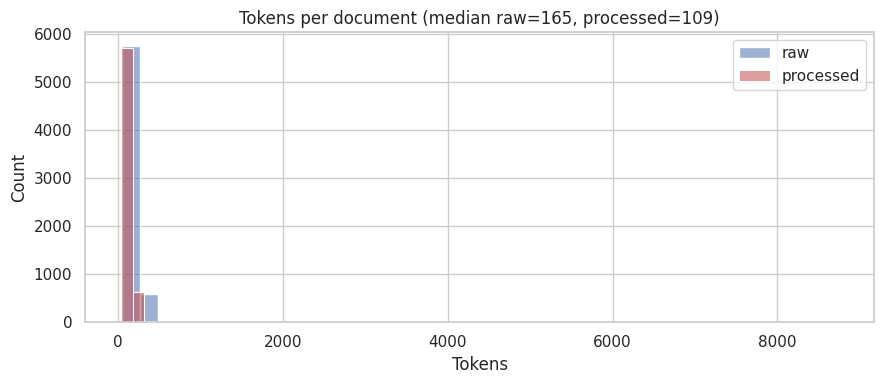

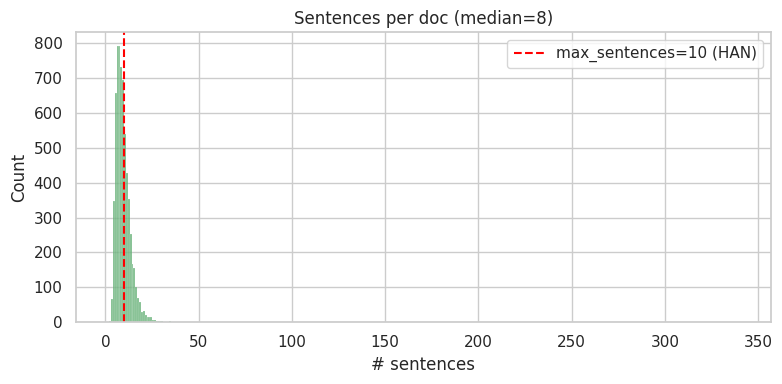

In [6]:
# Cellule 5 - Fonction visualisation EDA
def visualize_eda(df: pd.DataFrame):
    fig_pareto = plot_tag_frequency_pareto(df, cutoff_k=TOP_K_TAGS)
    fig_tags = plot_tag_distribution(df, top_n=TOP_K_TAGS)
    fig_cooc = plot_tag_cooccurrence_heatmap(df, top_n=min(TOP_K_TAGS, 15))
    fig_len = plot_text_length_distributions(df)
    fig_prep = plot_preprocessing_impact(df)
    fig_sents = plot_sentences_per_doc(df)
    plt.show()
    return {
        "pareto": fig_pareto,
        "tags": fig_tags,
        "cooc": fig_cooc,
        "lengths": fig_len,
        "preprocessing": fig_prep,
        "sentences": fig_sents,
    }


_ = visualize_eda(df)

In [7]:
# Cellule 6 - Préparation train/test
def make_splits(df: pd.DataFrame):
    return prepare_train_test(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )


X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = make_splits(df)
print("Train:", len(X_flat_train), "Test:", len(X_flat_test), "Labels:", len(mlb.classes_))
print("Hier train:", len(X_hier_train), "Hier test:", len(X_hier_test), "Labels:", len(mlb.classes_))


Train: 5757 Test: 640 Labels: 10
Hier train: 5757 Hier test: 640 Labels: 10


In [8]:
def train_models(X_flat_train, X_flat_test, y_train, y_test, n_topics: int, glove_path: str, threshold: float, topk: int):
    return run_all_models(
        X_train=X_flat_train,
        X_test=X_flat_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
        threshold=threshold,
        topk=topk,
    )

def train_models_hierarchical(X_hier_train, X_hier_test, y_train, y_test, n_topics: int, glove_path: str, threshold: float, topk: int):
    return run_all_models_hierarchical(
        X_hier_train=X_hier_train,
        X_hier_test=X_hier_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
        threshold=threshold,
        topk=topk,
    )


In [9]:
# Mode top-k (aligné article) — k calculé automatiquement depuis y_train
metrics_df, predictions, raw_probas, timings, histories = train_models(
    X_flat_train, X_flat_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None, # Pour etre coherent avec Wang et al. article 400.pdf
)
metrics_df

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13047 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/30
81/81 [==============================] - 23s 239ms/step - loss: 0.4894 - val_loss: 0.4629
Epoch 2/30
81/81 [==============================] - 19s 238ms/step - loss: 0.4518 - val_loss: 0.4433
Epoch 3/30
81/81 [==============================] - 19s 238ms/step - loss: 0.4218 - val_loss: 0.4082
Epoch 4/30
81/81 [==============================] - 19s 235ms/step - loss: 0.3880 - val_loss: 0.3787
Epoch 5/30
81/81 [==============================] - 19s 238ms/step - loss: 0.3606 - val_loss: 0.3530
Epoch 6/30
81/81 [==============================] - 20s 252ms/step - loss: 0.3418 - val_loss: 0.3425
Epoch 7/30
81/81 [==============================] - 21s 254ms/step - loss: 0.3304 - val_loss: 0.3315
E

2026-04-17 16:19:23.517747: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


81/81 [==============================] - 23s 167ms/step - loss: 0.5088 - val_loss: 0.4686
Epoch 2/30
81/81 [==============================] - 12s 151ms/step - loss: 0.4664 - val_loss: 0.4679
Epoch 3/30
81/81 [==============================] - 13s 165ms/step - loss: 0.4652 - val_loss: 0.4680
Epoch 4/30
81/81 [==============================] - 13s 163ms/step - loss: 0.4646 - val_loss: 0.4679
Epoch 5/30
81/81 [==============================] - 13s 165ms/step - loss: 0.4643 - val_loss: 0.4677
Epoch 6/30
81/81 [==============================] - 12s 147ms/step - loss: 0.4638 - val_loss: 0.4681
Epoch 7/30
81/81 [==============================] - 12s 152ms/step - loss: 0.4631 - val_loss: 0.4676
Epoch 8/30
81/81 [==============================] - 14s 169ms/step - loss: 0.4631 - val_loss: 0.4668
Epoch 9/30
81/81 [==============================] - 13s 162ms/step - loss: 0.4618 - val_loss: 0.4658
Epoch 10/30
81/81 [==============================] - 13s 158ms/step - loss: 0.4596 - val_loss: 0.4630


,name,micro_recall,micro_precision,micro_f1
0,Bi-GRU+Att,0.566724,0.693531,0.623748
1,SVM,0.490468,0.764865,0.597677
2,NB,0.757366,0.490736,0.595571
3,Paragraph Vector,0.538128,0.637577,0.583647
4,HAN_BiGRU_Att,0.391681,0.680723,0.497250
5,SVM_BOW,0.330156,0.793750,0.466340
6,LDA,0.220971,0.629630,0.327133
7,LDA_TFIDF,0.000867,0.500000,0.001730


In [11]:
seeds = [42, 123, 456, 789, 1024]
all_metrics = []
for seed in seeds:
    X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = prepare_train_test(df, random_state=seed)
    metrics, _, _, _, _ = train_models(
    X_flat_train, X_flat_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None,
    )
    metrics["seed"] = seed
    all_metrics.append(metrics)
df_all = pd.concat(all_metrics)
summary = df_all.groupby("name").agg(["mean", "std"])
summary

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13047 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/30
81/81 [==============================] - 6s 58ms/step - loss: 0.4933 - val_loss: 0.4648
Epoch 2/30
81/81 [==============================] - 4s 55ms/step - loss: 0.4556 - val_loss: 0.4493
Epoch 3/30
81/81 [==============================] - 4s 51ms/step - loss: 0.4265 - val_loss: 0.4126
Epoch 4/30
81/81 [==============================] - 5s 56ms/step - loss: 0.3898 - val_loss: 0.3789
Epoch 5/30
81/81 [==============================] - 5s 57ms/step - loss: 0.3640 - val_loss: 0.3611
Epoch 6/30
81/81 [==============================] - 4s 54ms/step - loss: 0.3478 - val_loss: 0.3453
Epoch 7/30
81/81 [==============================] - 4s 55ms/step - loss: 0.3357 - val_loss: 0.3364
Epoch 8/30
81/8

micro_recall           micro_precision            micro_f1  \
                         mean       std            mean       std      mean   
name                                                                          
Bi-GRU+Att           0.528964  0.018938        0.712951  0.018467  0.607201   
HAN_BiGRU_Att        0.294421  0.165789        0.557407  0.312217  0.385014   
LDA                  0.230049  0.030947        0.667078  0.039845  0.341039   
LDA_TFIDF            0.036083  0.028764        0.576132  0.061021  0.066241   
NB                   0.766688  0.008102        0.501711  0.018773  0.606383   
Paragraph Vector     0.530339  0.011921        0.629971  0.017877  0.575717   
SVM                  0.487983  0.015799        0.759822  0.018785  0.594028   
SVM_BOW              0.318150  0.010882        0.775354  0.018841  0.451087   

                             seed              
                       std   mean         std  
name                                           
Bi-GRU+Att        0.016561  486.8  421.620327  
HAN_BiGRU_Att     0.215971  486.8  421.620327  
LDA               0.035173  486.8  421.620327  
LDA_TFIDF         0.051379  486.8  421.620327  
NB                0.014614  486.8  421.620327  
Paragraph Vector  0.009759  486.8  421.620327  
SVM               0.010513  486.8  421.620327  
SVM_BOW           0.012518  486.8  421.620327

In [12]:
# Mode top-k (aligné article) — k calculé automatiquement depuis y_train
metrics_df, predictions, raw_probas, timings, histories = train_models_hierarchical(
    X_hier_train, X_hier_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None, # Pour etre coherent avec Wang et al. article 400.pdf
)
metrics_df

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13033 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/30
81/81 [==============================] - 7s 58ms/step - loss: 0.4892 - val_loss: 0.4682
Epoch 2/30
81/81 [==============================] - 4s 53ms/step - loss: 0.4572 - val_loss: 0.4602
Epoch 3/30
81/81 [==============================] - 5s 60ms/step - loss: 0.4430 - val_loss: 0.4312
Epoch 4/30
81/81 [==============================] - 5s 60ms/step - loss: 0.4085 - val_loss: 0.3889
Epoch 5/30
81/81 [==============================] - 4s 54ms/step - loss: 0.3761 - val_loss: 0.3572
Epoch 6/30
81/81 [==============================] - 5s 59ms/step - loss: 0.3515 - val_loss: 0.3400
Epoch 7/30
81/81 [==============================] - 4s 54ms/step - loss: 0.3371 - val_loss: 0.3344
Epoch 8/30
81/8

,name,micro_recall,micro_precision,micro_f1
0,NB,0.768856,0.533183,0.629691
1,Bi-GRU+Att,0.523925,0.749420,0.616706
2,SVM,0.472019,0.790761,0.591163
3,Paragraph Vector,0.524736,0.673958,0.590059
4,HAN_BiGRU_Att,0.472830,0.758127,0.582418
5,SVM_BOW,0.312247,0.797101,0.448718
6,LDA,0.256285,0.708520,0.376415
7,LDA_TFIDF,0.022709,0.736842,0.044060


In [13]:
seeds = [42, 123, 456, 789, 1024]
all_metrics = []
for seed in seeds:
    X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = prepare_train_test(df, random_state=seed)
    metrics, _, _, _, _ = train_models_hierarchical(
    X_hier_train, X_hier_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None,
    )
    metrics["seed"] = seed
    all_metrics.append(metrics)
df_all = pd.concat(all_metrics)
summary = df_all.groupby("name").agg(["mean", "std"])
summary

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13063 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/30
81/81 [==============================] - 6s 56ms/step - loss: 0.4905 - val_loss: 0.4663
Epoch 2/30
81/81 [==============================] - 5s 58ms/step - loss: 0.4581 - val_loss: 0.4558
Epoch 3/30
81/81 [==============================] - 5s 58ms/step - loss: 0.4402 - val_loss: 0.4306
Epoch 4/30
81/81 [==============================] - 5s 60ms/step - loss: 0.4075 - val_loss: 0.3985
Epoch 5/30
81/81 [==============================] - 5s 56ms/step - loss: 0.3728 - val_loss: 0.3635
Epoch 6/30
81/81 [==============================] - 5s 57ms/step - loss: 0.3506 - val_loss: 0.3514
Epoch 7/30
81/81 [==============================] - 5s 57ms/step - loss: 0.3373 - val_loss: 0.3370
Epoch 8/30
81/8

micro_recall           micro_precision            micro_f1  \
                         mean       std            mean       std      mean   
name                                                                          
Bi-GRU+Att           0.535504  0.018598        0.718703  0.022752  0.613398   
HAN_BiGRU_Att        0.485571  0.019428        0.712265  0.016328  0.577181   
LDA                  0.241550  0.018521        0.643533  0.045688  0.350819   
LDA_TFIDF            0.024282  0.010985        0.615016  0.083021  0.046401   
NB                   0.766861  0.007832        0.501586  0.018236  0.606354   
Paragraph Vector     0.532550  0.013206        0.640961  0.019151  0.581492   
SVM                  0.487997  0.016918        0.758782  0.019590  0.593712   
SVM_BOW              0.321403  0.012891        0.779617  0.017396  0.455063   

                             seed              
                       std   mean         std  
name                                           
Bi-GRU+Att        0.012808  486.8  421.620327  
HAN_BiGRU_Att     0.013349  486.8  421.620327  
LDA               0.022591  486.8  421.620327  
LDA_TFIDF         0.020626  486.8  421.620327  
NB                0.014228  486.8  421.620327  
Paragraph Vector  0.007699  486.8  421.620327  
SVM               0.012030  486.8  421.620327  
SVM_BOW           0.014501  486.8  421.620327

In [14]:
# If you still have 'predictions' dict from the last run:
y_pred_bigru = predictions["Bi-GRU+Att"]

print("=== Bi-GRU+Att Diagnostic ===")
print(f"y_test shape: {y_test.shape}")
print(f"y_test pos rate: {y_test.mean():.4f}")
print(f"y_test avg labels/doc: {y_test.sum(axis=1).mean():.2f}")
print()
print(f"y_pred shape: {y_pred_bigru.shape}")
print(f"y_pred pos rate: {y_pred_bigru.mean():.4f}")
print(f"y_pred avg labels/doc: {y_pred_bigru.sum(axis=1).mean():.2f}")
print()

# If you can access raw probas (before thresholding), inspect them:
# Otherwise, these stats on binary preds are already very telling
print(f"Docs with 0 predicted tags: {(y_pred_bigru.sum(axis=1) == 0).sum()}")
print(f"Docs with >10 predicted tags: {(y_pred_bigru.sum(axis=1) > 10).sum()}")
print(f"Docs with >20 predicted tags: {(y_pred_bigru.sum(axis=1) > 20).sum()}")

=== Bi-GRU+Att Diagnostic ===
y_test shape: (640, 10)
y_test pos rate: 0.1927
y_test avg labels/doc: 1.93

y_pred shape: (640, 10)
y_pred pos rate: 0.1347
y_pred avg labels/doc: 1.35

Docs with 0 predicted tags: 88
Docs with >10 predicted tags: 0
Docs with >20 predicted tags: 0


In [15]:
# Cellule 8 - Sauvegarde facultative des métriques
   
model_params = {
    "NB": {"vectorizer": "CountVectorizer", "max_features": 8000, "ngram_range": [1, 1], "threshold": 0.5},
    "SVM": {"vectorizer": "TfidfVectorizer", "max_features": 8000, "classifier": "CalibratedClassifierCV(LinearSVC", "threshold": 0.0},
    "LDA": {"num_topics": TOP_K_TAGS, "passes": 10, "iterations": 100, "threshold": 0.5},
    "Paragraph Vector": {"vector_size": 200, "window": 3, "epochs": 20, "threshold": 0.5},
    "Bi-GRU+Att": {"max_words": 15000, "max_len": 300, "gru_units": 25, "dense_units": 50, "dropout": 0.2, "epochs": 5, "batch_size": 64, "threshold": 0.5},
}

save_metrics_enriched(
    metrics_df=metrics_df,
    predictions=predictions,
    y_test=y_test,
    top_k_tags=TOP_K_TAGS,
    test_size=0.1,
    random_state=42,
    repeats=1,
    threshold=0.5,
    n_docs=len(df),
    n_unique_tags=len({t for tags in df["tag_list"] for t in tags}),
    avg_tags_per_doc=float(df["tag_list"].apply(len).mean()),
    glove_path=str(GLOVE_PATH),
    model_params=model_params,
    notes="first stable docker run",
)


(PosixPath('data/metrics_results_history_10.csv'), 'e7315c32ff60')

,name,micro_recall,micro_precision,micro_f1
0,NB,0.768856,0.533183,0.629691
1,Bi-GRU+Att,0.523925,0.749420,0.616706
2,SVM,0.472019,0.790761,0.591163
3,Paragraph Vector,0.524736,0.673958,0.590059
4,HAN_BiGRU_Att,0.472830,0.758127,0.582418
5,SVM_BOW,0.312247,0.797101,0.448718
6,LDA,0.256285,0.708520,0.376415
7,LDA_TFIDF,0.022709,0.736842,0.044060


[Fig] Model Comparison — barres groupées de micro-precision / micro-recall / micro-F1 pour chaque modèle. Meilleur modèle : NB (F1=0.630).
[Fig] Article vs Current — compare nos scores (micro P/R/F1) à ceux rapportés dans Wang et al. pour les mêmes modèles. Permet d'évaluer la reproduction.
[Fig] Precision vs Recall (iso-F1) — chaque point est un modèle, positionné selon son micro-recall (X) et sa micro-precision (Y). Les courbes grises pointillées sont les iso-F1 ; un modèle au-dessus d'une courbe dépasse ce F1. Point le plus au nord-est = meilleur compromis (NB, F1=0.630).
[Fig] Temps d'entraînement par modèle (échelle log) — plus rapide : NB (0.2s), plus lent : Bi-GRU+Att (155.9s). Ratio lent/rapide ≈ 673×.
[Fig] Courbes d'apprentissage (Bi-GRU+Att) — évolution de la loss par époque. Train loss finale = 0.2639, val loss finale = 0.2880. Si la val loss remonte alors que la train continue de baisser → signe d'overfitting ; early stopping (patience=5) s'en charge.
[Fig] Courbes d'appre

/workspace/src/visualization.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=s.values, y=s.index, ax=ax, palette="crest")


[Fig] Sensibilité au top-K — micro-F1 quand on force la prédiction des K tags les plus probables par document (K de 1 à 5). Permet de choisir K quand on veut un nombre fixe de recommandations plutôt qu'un seuil de probabilité.
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thr

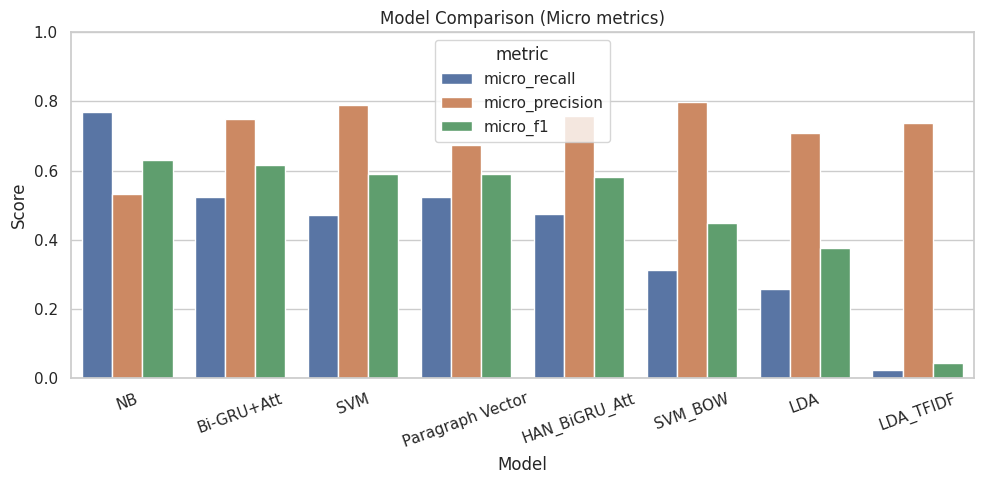

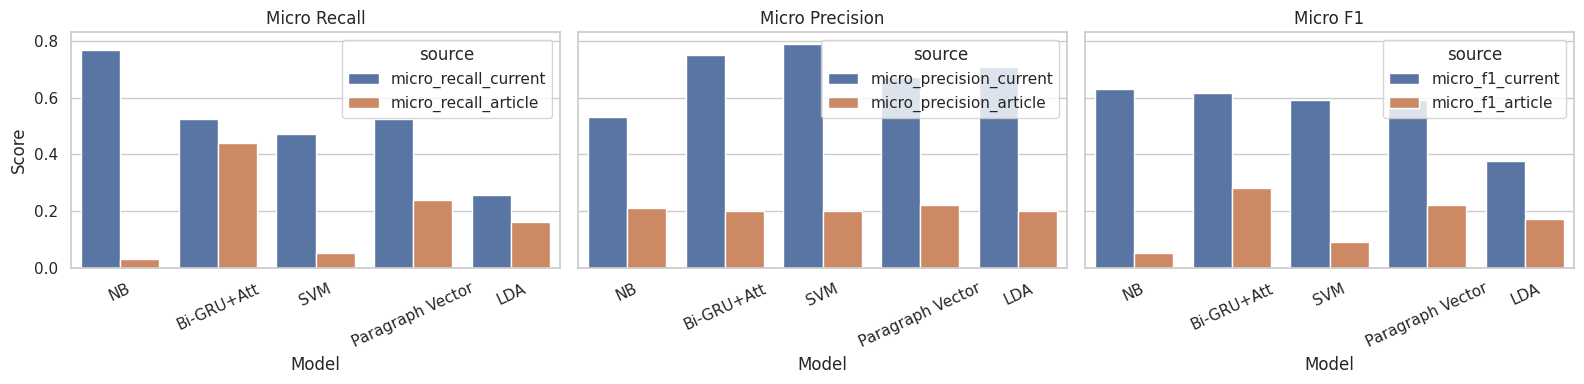

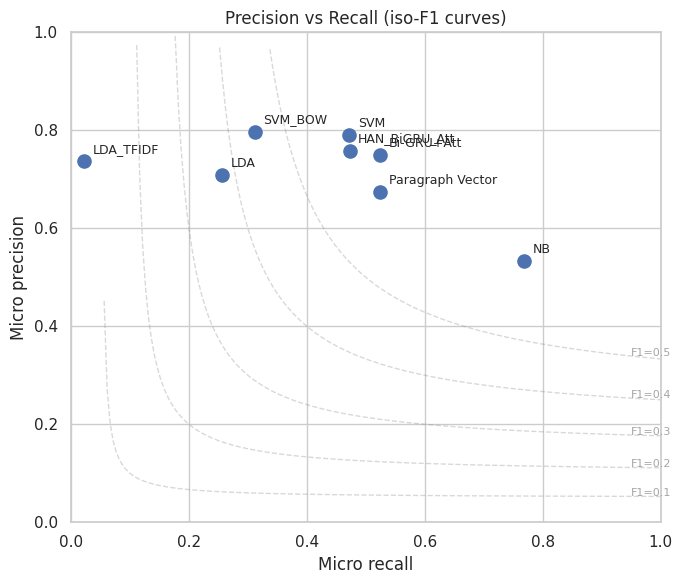

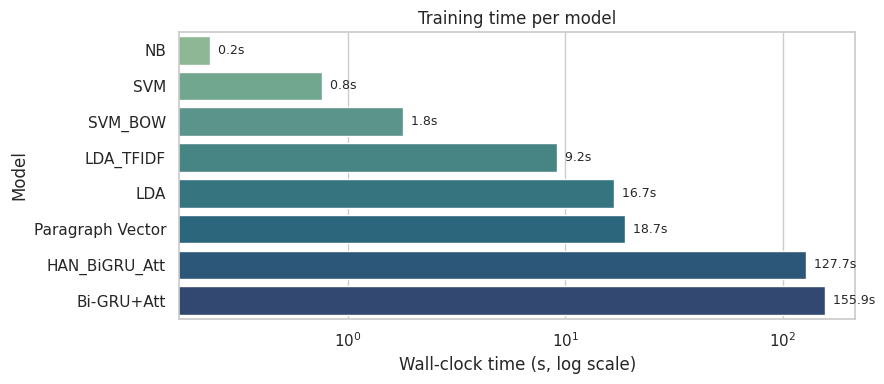

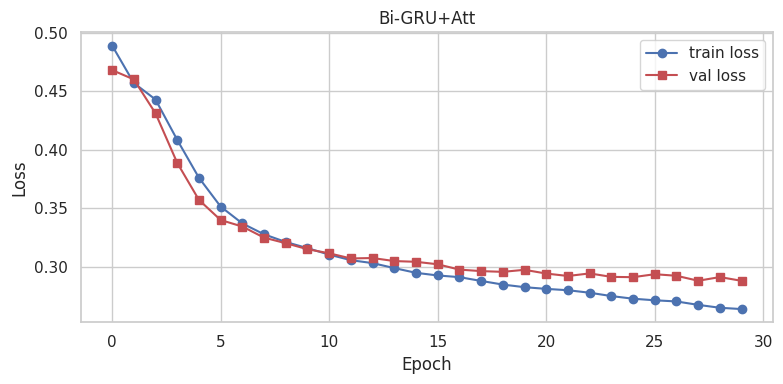

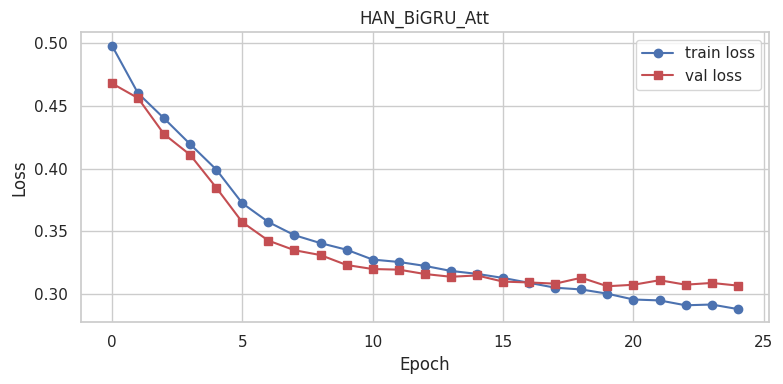

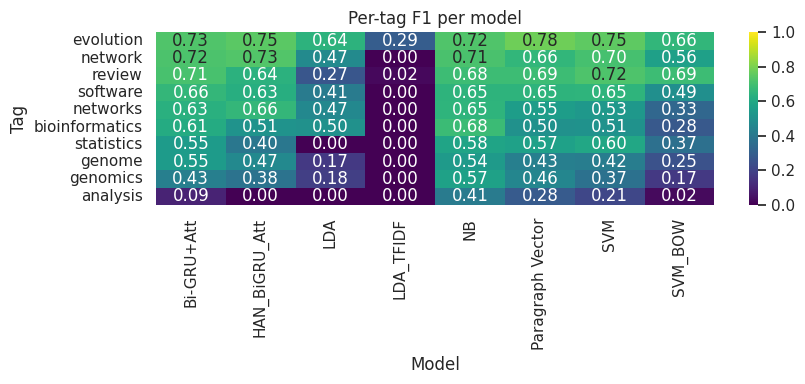

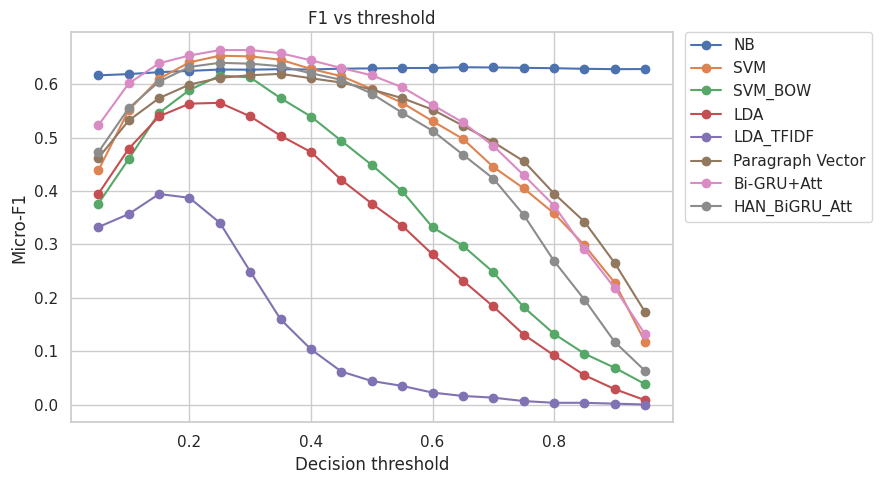

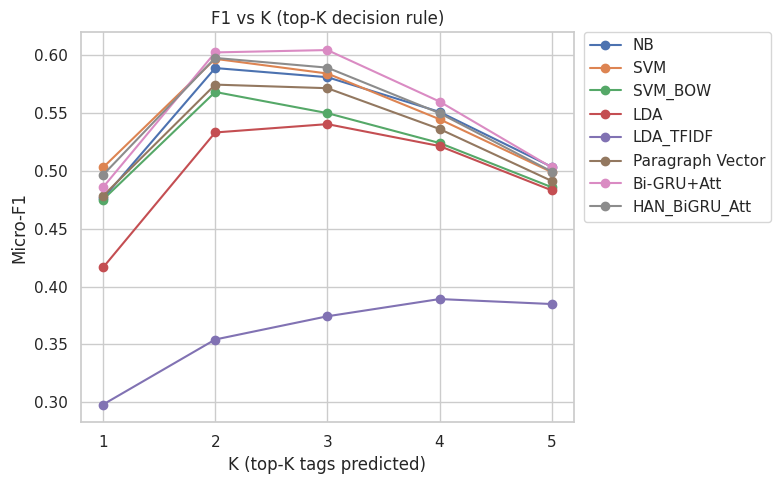

{'best_model': 'NB',
 'best_micro_f1': 0.6296911325141149,
 'timings_s': {'NB': 0.23,
  'SVM': 0.76,
  'SVM_BOW': 1.79,
  'LDA': 16.73,
  'LDA_TFIDF': 9.17,
  'Paragraph Vector': 18.74,
  'Bi-GRU+Att': 155.88,
  'HAN_BiGRU_Att': 127.74}}

In [16]:
# Cellule 9 (dernière) - Compilation + visualisations comparatives
def compile_and_compare(
    metrics_df: pd.DataFrame,
    predictions: dict,
    raw_probas: dict,
    timings: dict,
    histories: dict,
    y_test,
    mlb,
):
    display(metrics_df.sort_values("micro_f1", ascending=False).reset_index(drop=True))

    # --- 1. Comparaison synthétique des modèles ---
    fig_models = plot_model_metrics(metrics_df)
    fig_article = plot_article_vs_current(metrics_df)
    fig_pr = plot_precision_recall_scatter(metrics_df)

    # --- 2. Entraînement (temps + courbes pour les NN) ---
    fig_time = plot_training_time(timings)
    for nn_name in ("Bi-GRU+Att", "HAN_BiGRU_Att"):
        if nn_name in histories and histories[nn_name]:
            plot_training_history(histories[nn_name], title=nn_name)

    # --- 3. Diagnostic par tag / sensibilité ---
    fig_per_tag = plot_per_tag_f1(y_test, predictions, tag_names=mlb.classes_.tolist())
    fig_thr = plot_threshold_sensitivity(y_test, raw_probas)
    fig_topk = plot_topk_sensitivity(y_test, raw_probas, k_values=range(1, 6))
    plt.show()

    return {
        "best_model": metrics_df.sort_values("micro_f1", ascending=False).iloc[0]["name"],
        "best_micro_f1": float(metrics_df["micro_f1"].max()),
        "timings_s": {k: round(v, 2) for k, v in timings.items()},
    }


summary = compile_and_compare(
    metrics_df=metrics_df,
    predictions=predictions,
    raw_probas=raw_probas,
    timings=timings,
    histories=histories,
    y_test=y_test,
    mlb=mlb,
)
summary